In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Imports

In [1]:
%env PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True

env: PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True


In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision.models import efficientnet_b7, EfficientNet_B7_Weights
from sklearn.metrics import classification_report
import numpy as np
import matplotlib.pyplot as plt
import os
import io

**Set Seed**

In [4]:
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Load Dataset

In [5]:
#dataset_path
#train
#validation
#test

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define dataset directories
data_dir = "/kaggle/input/ibean-aug"
train_dir = f"{data_dir}/augmented_train"
val_dir = f"{data_dir}/augmented_validation"
test_dir = "/kaggle/input/ibeans-test-set/test"

# Define transformations
transform = transforms.Compose([
    transforms.Resize((380, 380)),  # Resize for EfficientNet-B7
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # Standard normalization
])

# Load datasets
train_dataset = ImageFolder(root=train_dir, transform=transform)
val_dataset = ImageFolder(root=val_dir, transform=transform)
test_dataset = ImageFolder(root=test_dir, transform=transform)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

**EDA**

In [6]:
len(train_dataset.classes)

3

# Model Building

**EfficientNET-FC (Custom linear layers)**

In [7]:
# EfficientNet with custom head
class EfficientNetWithCustomHead(nn.Module):
    def __init__(self, num_classes, hidden_dims=[512, 256, 128], dropout=0.3):
        super().__init__()
        self.base_model = efficientnet_b7(weights=EfficientNet_B7_Weights.IMAGENET1K_V1)
        self.features = self.base_model.features  # Keep only the feature extractor
        self.pooling = nn.AdaptiveAvgPool2d(1)
        in_features = self.base_model.classifier[1].in_features

        # Define custom classifier
        layers = []
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(in_features, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(inplace=True),
                nn.Dropout(p=dropout)
            ])
            in_features = hidden_dim
        layers.append(nn.Linear(in_features, num_classes))
        self.classifier = nn.Sequential(*layers)

    def forward(self, x):
        x = self.features(x)
        x = self.pooling(x).flatten(1)
        return self.classifier(x)


In [8]:
# Unfreeze EfficientNet layers in blocks
def unfreeze_layers(model, num_blocks=2):
    """
    Unfreeze the last `num_blocks` of EfficientNet blocks for fine-tuning.
    """
    # All layers frozen by default
    for param in model.features.parameters():
        param.requires_grad = False

    # Unfreeze last `num_blocks`
    for block in list(model.features.children())[-num_blocks:]:
        for param in block.parameters():
            param.requires_grad = True


In [9]:
model = EfficientNetWithCustomHead(num_classes=3).to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b7_lukemelas-c5b4e57e.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b7_lukemelas-c5b4e57e.pth
100%|██████████| 255M/255M [00:01<00:00, 234MB/s] 


**EfficientNET-LSTM (Custom LSTM layers)**

In [19]:
# EfficientNet with Custom LSTM layers and a linear head
class EfficientNetWithLSTMHead(nn.Module):
    def __init__(self, num_classes, hidden_dim=128, lstm_layers=1, bidirectional=False, dropout=0.5):
        super(EfficientNetWithLSTMHead, self).__init__()
        self.backbone = efficientnet_b7(weights=EfficientNet_B7_Weights.DEFAULT)
        self.backbone.classifier = nn.Identity()  # Remove original classifier

        # Freeze the feature extractor initially
        for param in self.backbone.parameters():
            param.requires_grad = False

        #self.pool = nn.AdaptiveAvgPool2d((1, 1))  # Average pool before LSTM
        
        self.lstm = nn.LSTM(
            input_size=2560,  # EfficientNet-B7 final feature dim
            hidden_size=hidden_dim,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if lstm_layers > 1 else 0.0
        )

        #self.bn = nn.BatchNorm1d(hidden_dim * 2 if bidirectional else hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2 if bidirectional else hidden_dim, num_classes)

    def forward(self, x):
        batch_size = x.size(0)
        features = self.backbone(x)  # [batch_size, 2560]
        # Reshape to [batch_size, sequence_len=1, features]
        lstm_input = features.unsqueeze(1)
        lstm_out, _ = self.lstm(lstm_input)  # [batch_size, 1, hidden_dim * 2]
        out = lstm_out[:, -1, :]  # Take the output of the last timestep
        out = self.dropout(out)
        out = self.fc(out)
        return out

    '''def forward(self, x):
        # Extract feature maps: (B, 2560, H/32, W/32)
        features = self.backbone.features(x)

        # Apply global average pooling: (B, 2560, 1, 1)
        pooled = self.pool(features)

        # Flatten spatial dims: (B, 2560)
        flattened = pooled.view(pooled.size(0), -1)

        # Add sequence dimension for LSTM: (B, 1, 2560)
        lstm_input = flattened.unsqueeze(1)

        lstm_out, _ = self.lstm(lstm_input)     # (B, 1, hidden_dim * num_directions)
        out = lstm_out[:, -1, :]                # Last time step output: (B, hidden_dim * num_directions)

        out = self.bn(out)
        out = self.dropout(out)
        out = self.fc(out)
        return out'''

In [20]:
model = EfficientNetWithLSTMHead(num_classes=3, lstm_layers=1).to(device)

In [21]:
# unfreeze_layers func for LSTM head
def unfreeze_layers(model, num_blocks=2):
    """
    Unfreeze the last `num_blocks` of EfficientNet blocks for fine-tuning.
    Assumes the EfficientNet model is stored in model.backbone.
    """
    # Ensure the model has a backbone with features
    assert hasattr(model, 'backbone'), "Model must have a .backbone attribute"
    assert hasattr(model.backbone, 'features'), "Backbone must have a .features attribute"

    # First, freeze all layers
    for param in model.backbone.features.parameters():
        param.requires_grad = False

    # Then unfreeze last num_blocks
    if num_blocks > 0:
        for block in list(model.backbone.features.children())[-num_blocks:]:
            for param in block.parameters():
                param.requires_grad = True


In [22]:
unfreeze_layers(model, num_blocks=0)

In [23]:
# Criterion and Optimizer
# ----- Run for each model (FC and LSTM) ----

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=5e-4)  # Train only classifier
#optimizer = optim.Adam(model.classifier.parameters(), lr=5e-5)  # Train only classifier (works for EfficientNET-B0)


In [11]:
# Get number of trainable parameters
def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Get model size
def get_model_size_in_mb(model):
    buffer = io.BytesIO()
    torch.save(model.state_dict(), buffer)
    size_mb = buffer.getbuffer().nbytes / (1024 * 1024)
    return size_mb

In [24]:
# Get number of trainable params & model size before training
trainable_params = count_trainable_params(model)
print(f"Trainable parameters: {trainable_params:,}")

print(f"Model size: {get_model_size_in_mb(model):.2f} MB")

Trainable parameters: 1,377,667
Model size: 250.20 MB


In [13]:
#Training Loop
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler=None,
    epochs=30,
    resume=True,
    patience=5,
    checkpoint_interval=10,
    checkpoint_path="/kaggle/working/checkpoint.pth",
    best_model_path="best_model.pth",
    start_epoch=0,
    unfreeze_step=5,  # unfreeze more layers every `unfreeze_step` epochs
    max_unfreeze_blocks=7
):
    best_val_loss = float("inf")
    epochs_no_improve = 0
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    # Resume training if checkpoint exists
    if resume and os.path.exists(checkpoint_path):
        checkpoint = torch.load(checkpoint_path)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_val_loss = checkpoint['best_val_loss']
        print(f"Resumed training from epoch {start_epoch}")

    for epoch in range(start_epoch, epochs):
        model.train()
        running_loss = 0.0
        correct, total = 0, 0

        # Gradually unfreeze more blocks
        if epoch % unfreeze_step == 0:
            num_to_unfreeze = min((epoch // unfreeze_step), max_unfreeze_blocks)
            unfreeze_layers(model, num_blocks=num_to_unfreeze)
            print(f"[Epoch {epoch+1}] Unfroze {num_to_unfreeze} EfficientNet blocks.")

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_acc = 100 * correct / total
        val_acc, val_loss = validate_model(model, val_loader, criterion)

        train_losses.append(running_loss / len(train_loader))
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        print(f"Epoch {epoch+1}: Loss: {running_loss/len(train_loader):.4f}, "
              f"Train Acc: {train_acc:.2f}%, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

        # Step the scheduler if provided
        if scheduler:
            scheduler.step(val_loss)

        # Save checkpoint every `checkpoint_interval` epochs
        if (epoch + 1) % checkpoint_interval == 0:
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_val_loss': best_val_loss
            }, checkpoint_path)
            print(f"[Checkpoint] Saved at epoch {epoch + 1}")

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            #torch.save(model.state_dict(), best_model_path)
            print(f"[Best Model] Saved at epoch {epoch + 1}")
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            print(f"[Early Stopping] {epochs_no_improve} epochs with no improvement.")

        # Early stopping
        if epochs_no_improve >= patience:
            print(f"[Early Stopping] No improvement for {patience} epochs. Stopping training.")
            # Save final checkpoint
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_val_loss': best_val_loss
            }, checkpoint_path)
            break

    # Final model save at the end of all epochs (if not already stopped)
    if epochs_no_improve < patience:
        torch.save({
            'epoch': epochs,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_loss': best_val_loss
        }, checkpoint_path)
        print(f"[Final Checkpoint] Training completed. Model saved at epoch {epochs}.")

    # Plot metrics
    plot_training_curves(train_losses, val_losses, train_accuracies, val_accuracies)


In [14]:
# Validation & Test loop
def validate_model(model, val_loader, criterion):
    model.eval()
    correct = 0
    total = 0
    running_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    val_acc = 100 * correct / total
    return val_acc, running_loss / len(val_loader)


def test_model(model, test_loader):
    model.eval()
    y_true = []
    y_pred = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    # Compute classification report
    class_names = train_dataset.classes
    report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
    print("\nClassification Report:\n", report)

In [15]:
# Function to plot training curves
# 🔹 **Plot Training Curves**
def plot_training_curves(train_losses, val_losses, train_accuracies, val_accuracies):
    epochs = range(1, len(train_losses) + 1)
    
    # Loss plot
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Train Loss')
    plt.plot(epochs, val_losses, label='Val Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss Curve')

    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, label='Train Accuracy')
    plt.plot(epochs, val_accuracies, label='Val Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.title('Accuracy Curve')

    plt.show()

[Epoch 1] Unfroze 0 EfficientNet blocks.
Epoch 1: Loss: 0.3178, Train Acc: 87.82%, Val Loss: 0.1873, Val Acc: 93.16%
[Best Model] Saved at epoch 1
Epoch 2: Loss: 0.1930, Train Acc: 92.76%, Val Loss: 0.1643, Val Acc: 94.23%
[Best Model] Saved at epoch 2
Epoch 3: Loss: 0.1539, Train Acc: 94.19%, Val Loss: 0.1609, Val Acc: 94.04%
[Best Model] Saved at epoch 3
Epoch 4: Loss: 0.1350, Train Acc: 95.00%, Val Loss: 0.1646, Val Acc: 94.21%
[Early Stopping] 1 epochs with no improvement.
Epoch 5: Loss: 0.1274, Train Acc: 95.35%, Val Loss: 0.1670, Val Acc: 94.36%
[Early Stopping] 2 epochs with no improvement.
[Epoch 6] Unfroze 1 EfficientNet blocks.
Epoch 6: Loss: 0.1544, Train Acc: 95.27%, Val Loss: 0.1565, Val Acc: 95.23%
[Best Model] Saved at epoch 6
Epoch 7: Loss: 0.0739, Train Acc: 97.60%, Val Loss: 0.1374, Val Acc: 96.13%
[Best Model] Saved at epoch 7
Epoch 8: Loss: 0.0474, Train Acc: 98.51%, Val Loss: 0.1021, Val Acc: 96.30%
[Best Model] Saved at epoch 8
Epoch 9: Loss: 0.0385, Train Acc: 98

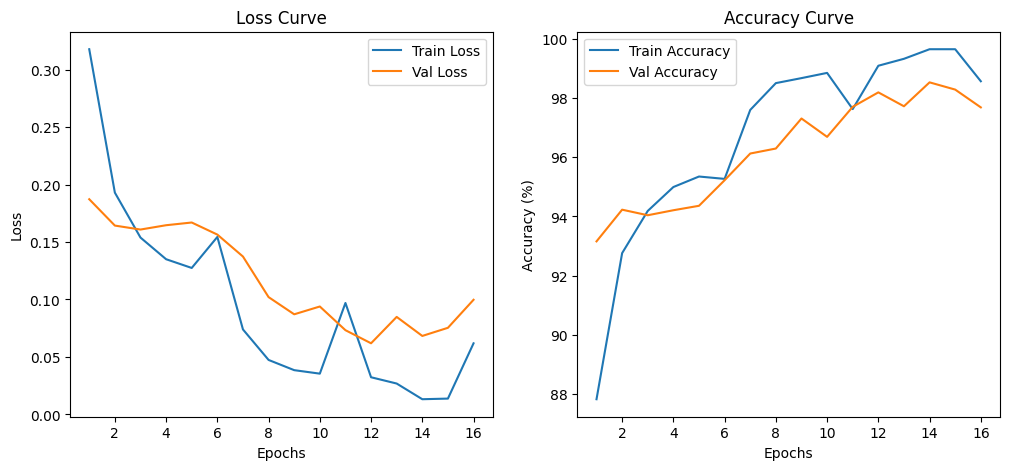

In [26]:
# Train, validate, and test the model
train_model(model, train_loader, val_loader, criterion, optimizer, epochs=16, resume=False)

In [27]:
test_model(model, test_loader)


Classification Report:
                    precision    recall  f1-score   support

angular_leaf_spot     0.9762    0.9535    0.9647        43
        bean_rust     0.9545    0.9767    0.9655        43
          healthy     1.0000    1.0000    1.0000        42

         accuracy                         0.9766       128
        macro avg     0.9769    0.9767    0.9767       128
     weighted avg     0.9767    0.9766    0.9766       128



In [28]:
# Get number of trainable params & model size after training
trainable_params = count_trainable_params(model)
print(f"Trainable parameters: {trainable_params:,}")

print(f"Model size: {get_model_size_in_mb(model):.2f} MB")

Trainable parameters: 52,844,795
Model size: 250.20 MB


In [18]:
# Plot the log for best model
plot_training_curves(train_losses[:16], val_losses[:16], train_accuracies[:16], val_accuracies[:16])

NameError: name 'train_losses' is not defined

In [20]:
# Use the best model

In [24]:
model_ = EfficientNetWithLSTMHead(num_classes=3, hidden_dim=128, lstm_layers=1)
model_.to(device)

EfficientNetWithLSTMHead(
  (backbone): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)
              (1): BatchNorm2d(64, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(64, 16, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
    

In [25]:
checkpoint = torch.load("/kaggle/working/checkpoint.pth", map_location=device)
model_.load_state_dict(checkpoint['model_state_dict'])
model_.eval()  # Important: Set model to evaluation mode

EfficientNetWithLSTMHead(
  (backbone): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)
              (1): BatchNorm2d(64, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(64, 16, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
    

In [33]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_(images)
        preds = torch.argmax(outputs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


In [34]:
class_names = ['angular_leaf_spot', 'bean_rust', 'healthy']

from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

                   precision    recall  f1-score   support

angular_leaf_spot     0.9773    1.0000    0.9885        43
        bean_rust     1.0000    0.9767    0.9882        43
          healthy     1.0000    1.0000    1.0000        42

         accuracy                         0.9922       128
        macro avg     0.9924    0.9922    0.9922       128
     weighted avg     0.9924    0.9922    0.9922       128

